In [1]:
import re
import torch
import pandas as pd
import torch.nn as nn
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from torch_geometric.data import Data, Batch
from torch_geometric.nn import GATConv, global_mean_pool, global_max_pool
from transformers import AutoTokenizer, AutoModel
from tqdm import tqdm
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import networkx as nx

In [2]:
# =========================
# CONFIG
# =========================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_NAME = "google-bert/bert-base-multilingual-uncased"
MAX_LEN = 298
BATCH_SIZE = 16
LR = 2e-5
EPOCHS = 3

In [3]:
# =========================
# dataset
# =========================
class TextDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = texts
        self.labels = labels

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        return self.texts[idx], self.labels[idx]

In [4]:
# =========================
# tokenizer
# =========================
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def collate_fn(batch):
    texts, labels = zip(*batch)

    enc = tokenizer(
        list(texts),
        padding=True,
        truncation=True,
        max_length=MAX_LEN,
        return_tensors="pt"
    )

    return enc, torch.tensor(labels)

In [5]:
# =========================
# MODEL
# =========================
class BertGAT(nn.Module):
    def __init__(self, model_name, hidden_dim=128, num_classes=2):
        super().__init__()

        self.bert = AutoModel.from_pretrained(model_name)
        #На выходе BERT dim=768 -> 4 блока Attention -> hid_dim * 4 -> hid_dim -> FC -> class
        self.gat1 = GATConv(768, hidden_dim, heads=4, edge_dim=1, dropout=0.2)
        self.gat2 = GATConv(hidden_dim * 4, hidden_dim, heads=1, edge_dim=1, dropout=0.2)

        self.fc = nn.Sequential(
            nn.Linear(hidden_dim * 2, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    # =========================
    # GRAPH BUILDING (full semantic)
    # =========================
    def build_graph(self, x, k=3):
        #Полностью семантический граф на косинусной близости
        n = x.size(0)
        device = x.device

        # Нормализуем для корректного косинусного сходства
        x_norm = torch.nn.functional.normalize(x, p=2, dim=1)

        # считаем кос. сходство
        sim = torch.matmul(x_norm, x_norm.T)

        # убираем петли (т.к sim = 1  у них)
        sim.fill_diagonal_(float('-inf'))

        k_eff = min(k, n - 1)

        # Отбираем top-k по близости слова
        topk = torch.topk(sim, k=k_eff, dim=1)
        # индексы токенов
        idx = torch.arange(n, device=device)
        # idx.unsqueeze(1) → [n, 1] -> .expand(n, k_eff) → [n, k] -> .reshape(-1) → flatten → [n*k]
        src = idx.unsqueeze(1).expand(n, k_eff).reshape(-1)
        #Берем индексы наших ближайших узлов и Flatten
        dst = topk.indices.reshape(-1)

        # Построение графа (неориентированный)
        edge_index = torch.stack(
            [torch.cat([src, dst]), torch.cat([dst, src])],
            dim=0
        )

        # Добавляем ребру вес в виде косинусного сходства, который подается в модель
        edge_attr = sim[src, dst]
        edge_attr = torch.cat([edge_attr, edge_attr], dim=0)

        # reshape [E] → [E, 1]  ([num_edges, num_features])
        edge_attr = edge_attr.unsqueeze(1)

        return edge_index, edge_attr
    # =========================
    # FORWARD
    # =========================
    def forward(self, enc):
        # enc содержит input_ids и attention_mask от tokenizer
        enc = {k: v.to(DEVICE) for k, v in enc.items()}

        # Получение контекстных эмбеддингов BERT
        out = self.bert(**enc)
        hidden = out.last_hidden_state  # [B, L, 768]
        # каждый текст → отдельный граф
        data_list = []

        for i in range(hidden.size(0)):
            # attention_mask: отделяем токены от padding
            mask = enc["attention_mask"][i]
            x = hidden[i][mask == 1]

            # Построение семантического графа
            edge_index, edge_attr = self.build_graph(x)

            # сохраняем:
            # x → node embeddings
            # edge_index → структура графа
            # edge_attr → веса рёбер
            data_list.append(Data(
                x=x,
                edge_index=edge_index,
                edge_attr=edge_attr
            ))

        # добавляется batch vector, указывающий принадлежность узлов
        batch_graph = Batch.from_data_list(data_list)

        #Прокидываем через сеть
        x = self.gat1(batch_graph.x, batch_graph.edge_index, batch_graph.edge_attr)
        x = torch.relu(x)

        x = self.gat2(x, batch_graph.edge_index, batch_graph.edge_attr)
        x = torch.relu(x)

        # преобразуем набор узлов → один вектор текста
        # Объединяем max и mean (Подразумевая, что получаем представление в общем
        # и то что повлияло очень сильно, думаю для тональности хорошая идея)
        x_mean = global_mean_pool(x, batch_graph.batch)
        x_max = global_max_pool(x, batch_graph.batch)
        x = torch.cat([x_mean, x_max], dim=1)

        return self.fc(x)

In [6]:
# =========================
# TRAIN
# =========================
def train(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0

    for data, labels in tqdm(loader):
        data, labels = data.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        out = model(data)

        loss = criterion(out, labels)
        loss.backward()

        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(loader)

In [7]:
# =========================
# EVAL
# =========================
@torch.no_grad()
def evaluate(model, loader):
    model.eval()

    correct = 0
    total = 0
    loss_sum = 0
    all_preds = []
    all_labels = []

    criterion = nn.CrossEntropyLoss()

    for data, labels in tqdm(loader):
        data, labels = data.to(DEVICE), labels.to(DEVICE)

        out = model(data)
        loss = criterion(out, labels)

        pred = out.argmax(dim=1)

        correct += (pred == labels).sum().item()
        total += labels.size(0)
        loss_sum += loss.item()

        all_preds.extend(pred.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    acc = correct / total
    f1 = f1_score(all_labels, all_preds, average="macro")

    return loss_sum / len(loader), acc, f1

In [8]:
# =========================
# RUN
# =========================

train_df = pd.read_parquet("train.parquet")
val_df = pd.read_parquet("val.parquet")
test_df = pd.read_parquet("test.parquet")

In [9]:
#Отбираем из большого датасета рандомные комменты, но сохраняя баланс классов
train_dataset = TextDataset(
    train_df["text"].tolist(),
    train_df["target"].tolist()
)

val_dataset = TextDataset(
    val_df["text"].tolist(),
    val_df["target"].tolist()
)

test_dataset = TextDataset(
    test_df["text"].tolist(),
    test_df["target"].tolist()
)


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    collate_fn=collate_fn
)

In [10]:
model = BertGAT(MODEL_NAME).to(DEVICE)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()

history      = []
best_val_acc = 0
for epoch in range(EPOCHS):
    train_loss                = train(model, train_loader, optimizer, criterion)
    val_loss, val_acc, val_f1 = evaluate(model, val_loader)
    history.append({'epoch': epoch, 'train_loss': train_loss,
                    'val_loss': val_loss, 'val_acc': val_acc, 'val_f1': val_f1})

    print(f'Epoch {epoch:02d} | '
          f'train_loss={train_loss:.4f} | '
          f'val_loss={val_loss:.4f} | '
          f'val_acc={val_acc:.4f} | '
          f'val_f1={val_f1:.4f}')
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_model/model.pt")
        tokenizer.save_pretrained("best_model/tokenizer")
        if hasattr(model, "config"):
            model.config.save_pretrained("best_model/config")


print('\n=== Финальная оценка на тестовой выборке ===')
test_loss, test_acc, test_f1 = evaluate(model, test_loader)
print(f'test_loss={test_loss:.4f} | test_acc={test_acc:.4f} | test_f1={test_f1:.4f}')

  0%|          | 0/6250 [00:00<?, ?it/s]d:\Deluxe\Progs\anaconda3\Lib\site-packages\torch_geometric\utils\_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
100%|██████████| 1250/1250 [00:54<00:00, 22.83it/s]


Epoch 00 | train_loss=0.4394 | val_loss=0.3846 | val_acc=0.8288 | val_f1=0.8287


  0%|          | 0/6250 [00:00<?, ?it/s]d:\Deluxe\Progs\anaconda3\Lib\site-packages\torch_geometric\utils\_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
100%|██████████| 1250/1250 [00:54<00:00, 22.79it/s]


Epoch 01 | train_loss=0.3569 | val_loss=0.3885 | val_acc=0.8232 | val_f1=0.8222


  0%|          | 0/6250 [00:00<?, ?it/s]d:\Deluxe\Progs\anaconda3\Lib\site-packages\torch_geometric\utils\_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
100%|██████████| 1250/1250 [00:47<00:00, 26.29it/s]


Epoch 02 | train_loss=0.2925 | val_loss=0.3941 | val_acc=0.8320 | val_f1=0.8319

=== Финальная оценка на тестовой выборке ===


100%|██████████| 625/625 [00:24<00:00, 25.28it/s]

test_loss=0.4082 | test_acc=0.8292 | test_f1=0.8291


In [11]:
def preprocess(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"\S+\.\S+/\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

In [12]:
def predict_text(text, model, tokenizer):
    model.eval()

    text = preprocess(text)

    enc = tokenizer(
        text,
        truncation=True,
        padding=True,
        max_length=MAX_LEN,
        return_tensors="pt"
    )

    enc = {k: v.to(DEVICE) for k, v in enc.items()}

    with torch.no_grad():
        out = model(enc)
        probs = torch.softmax(out, dim=-1)
        pred = probs.argmax(dim=1).item()

    return pred, probs.cpu().numpy()

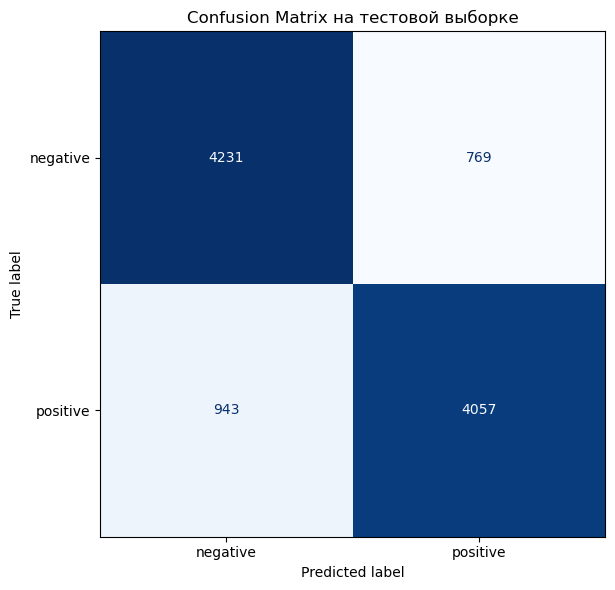

In [13]:
@torch.no_grad()
def get_all_predictions(model, loader, device):
    model.eval()

    all_preds = []
    all_labels = []

    for enc, labels in loader:
        enc = {k: v.to(device) for k, v in enc.items()}
        labels = labels.to(device)

        out = model(enc)
        pred = out.argmax(dim=1)

        all_preds.extend(pred.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    return all_labels, all_preds


model.load_state_dict(torch.load("best_model.pt"))
true_labels, pred_labels = get_all_predictions(model, test_loader, DEVICE)

cm   = confusion_matrix(true_labels, pred_labels)
disp = ConfusionMatrixDisplay(cm, display_labels=['negative', 'positive'])

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix на тестовой выборке')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

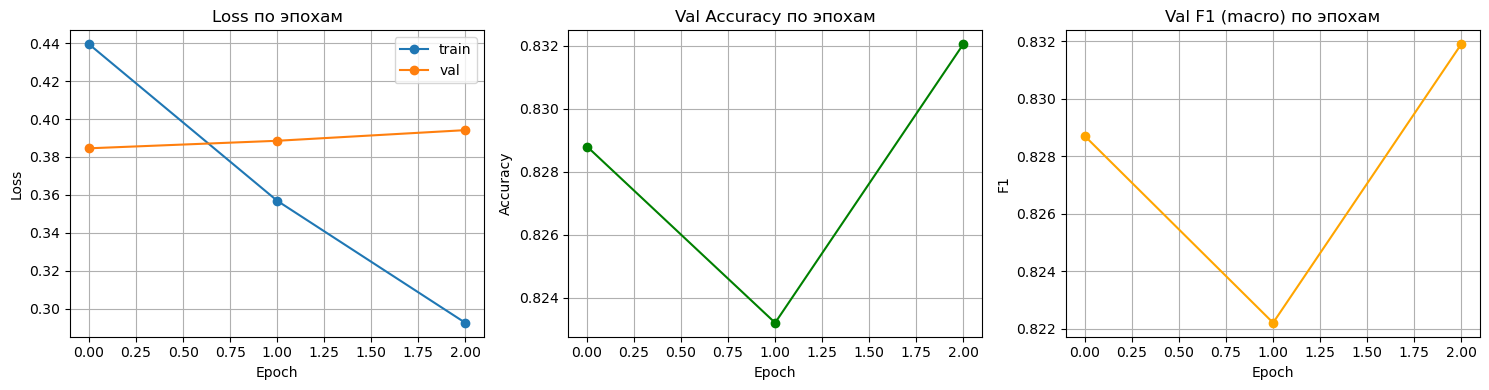

In [14]:
epochs     = [h['epoch']     for h in history]
train_loss = [h['train_loss'] for h in history]
val_loss   = [h['val_loss']   for h in history]
val_acc    = [h['val_acc']    for h in history]
val_f1     = [h['val_f1']     for h in history]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss
axes[0].plot(epochs, train_loss, label='train', marker='o')
axes[0].plot(epochs, val_loss,   label='val',   marker='o')
axes[0].set_title('Loss по эпохам')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy
axes[1].plot(epochs, val_acc, color='green', marker='o')
axes[1].set_title('Val Accuracy по эпохам')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].grid(True)

# F1
axes[2].plot(epochs, val_f1, color='orange', marker='o')
axes[2].set_title('Val F1 (macro) по эпохам')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('F1')
axes[2].grid(True)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
def visualize_tweet_graph(text: str, model, tokenizer, max_tokens: int = 298, k: int = 3):
    model.eval()

    text = preprocess(text)

    enc = tokenizer(
        text,
        truncation=True,
        padding=True,
        max_length=max_tokens,
        return_tensors="pt"
    )

    enc = {k: v.to(DEVICE) for k, v in enc.items()}

    with torch.no_grad():
        out = model.bert(**enc)
        hidden = out.last_hidden_state[0]  # [L, 768]

        mask = enc["attention_mask"][0].bool()
        x = hidden[mask == 1]

        x_norm = torch.nn.functional.normalize(x, p=2, dim=1)

        sim = torch.matmul(x_norm, x_norm.T)
        sim.fill_diagonal_(float("-inf"))

        k_eff = min(k, x.size(0) - 1)
        topk = torch.topk(sim, k=k_eff, dim=1)

        n = x.size(0)

        G = nx.DiGraph()

        tokens = tokenizer.convert_ids_to_tokens(enc["input_ids"][0][mask])

        for i in range(n):
            G.add_node(i, label=tokens[i])

        src_list = []
        dst_list = []
        weights = []

        for i in range(n):
            for j, w in zip(topk.indices[i].tolist(), topk.values[i].tolist()):
                src_list.append(i)
                dst_list.append(j)
                weights.append(w)

        for i, j, w in zip(src_list, dst_list, weights):
            G.add_edge(i, j, weight=w)

        pos = nx.spring_layout(G, seed=42, k=1.5)

        labels = {i: tokens[i] for i in range(n)}

        # цвета: subword vs wordpiece
        colors = [
            "#FF6B6B" if tok.startswith("##") else "#4ECDC4"
            for tok in tokens
        ]

        # вес рёбер → прозрачность
        edge_alphas = [(w + 1) / 2 for w in weights]  # normalize approx

        fig, ax = plt.subplots(figsize=(12, 7))

        nx.draw_networkx_nodes(
            G, pos,
            node_color=colors,
            node_size=900,
            ax=ax
        )

        nx.draw_networkx_labels(
            G, pos,
            labels,
            font_size=9,
            font_weight="bold",
            ax=ax
        )

        # draw edges with weights
        for (i, j, w), alpha in zip(zip(src_list, dst_list, weights), edge_alphas):
            nx.draw_networkx_edges(
                G, pos,
                edgelist=[(i, j)],
                alpha=alpha,
                arrows=True,
                arrowsize=12,
                edge_color="gray",
                ax=ax
            )

        from matplotlib.patches import Patch

        legend = [
            Patch(color="#4ECDC4", label="wordpiece / token"),
            Patch(color="#FF6B6B", label="## subword"),
        ]

        ax.legend(handles=legend, loc="upper right")

        ax.set_title(
            f"Semantic kNN Graph (GAT input): \"{text[:60]}...\""
            if len(text) > 60 else f"Semantic kNN Graph (GAT input): \"{text}\""
        )

        ax.axis("off")
        plt.tight_layout()
        plt.show()

        print(f"Tokens: {n}")
        print(f"Edges: {len(src_list)}")
        print(f"Top tokens: {tokens}")

────────────────────────────────────────────────────────────


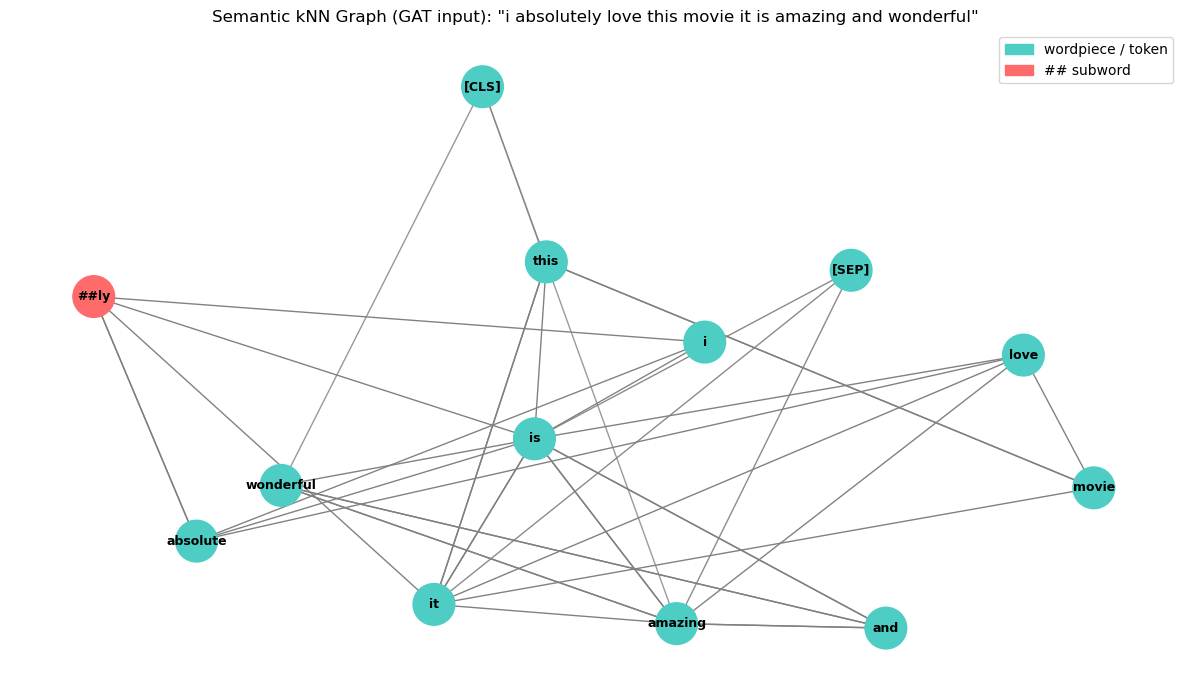

Tokens: 13
Edges: 39
Top tokens: ['[CLS]', 'i', 'absolute', '##ly', 'love', 'this', 'movie', 'it', 'is', 'amazing', 'and', 'wonderful', '[SEP]']
────────────────────────────────────────────────────────────


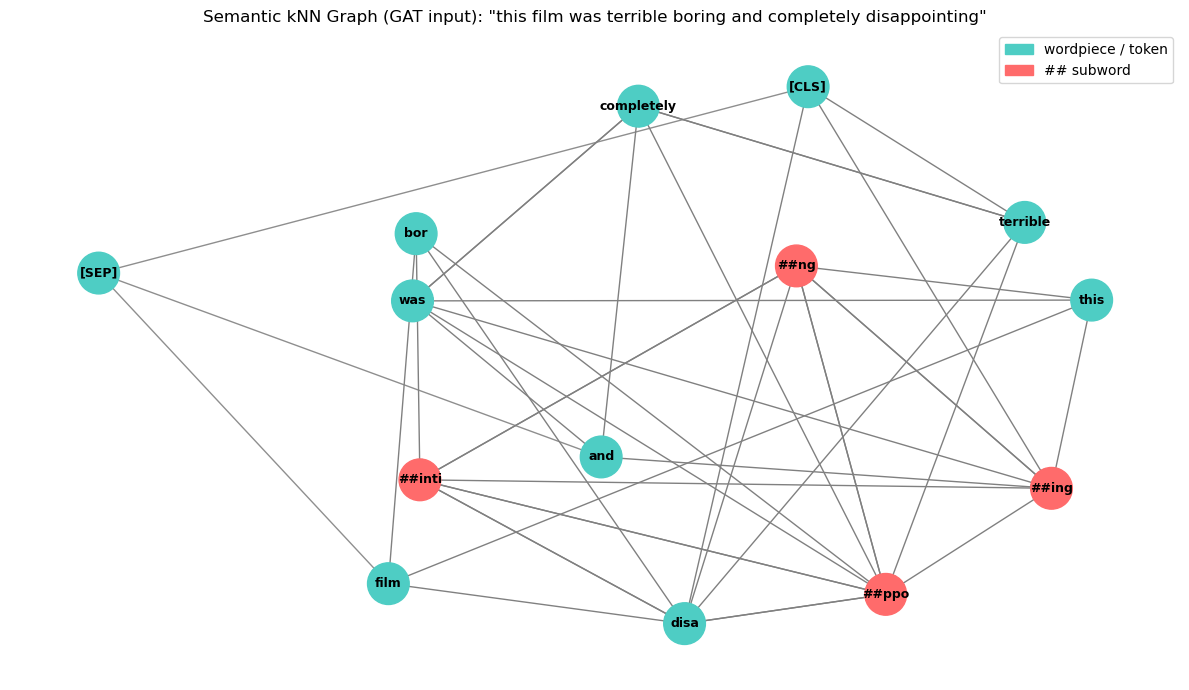

Tokens: 14
Edges: 42
Top tokens: ['[CLS]', 'this', 'film', 'was', 'terrible', 'bor', '##ing', 'and', 'completely', 'disa', '##ppo', '##inti', '##ng', '[SEP]']
────────────────────────────────────────────────────────────


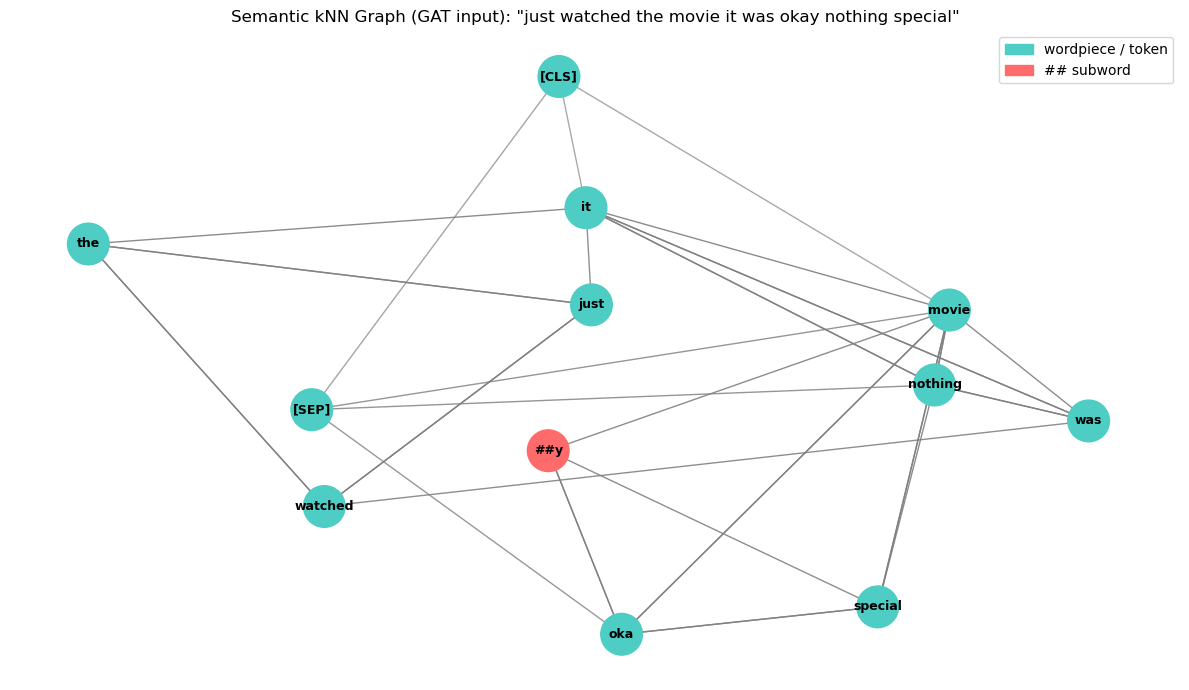

Tokens: 12
Edges: 36
Top tokens: ['[CLS]', 'just', 'watched', 'the', 'movie', 'it', 'was', 'oka', '##y', 'nothing', 'special', '[SEP]']
────────────────────────────────────────────────────────────


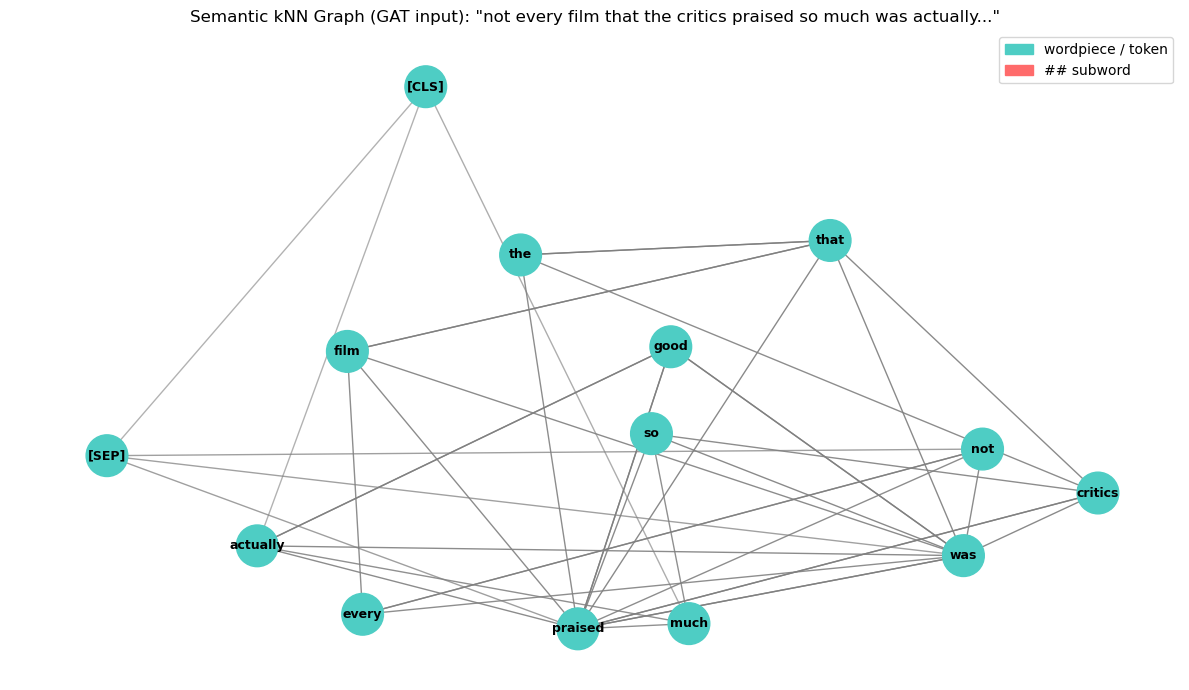

Tokens: 14
Edges: 42
Top tokens: ['[CLS]', 'not', 'every', 'film', 'that', 'the', 'critics', 'praised', 'so', 'much', 'was', 'actually', 'good', '[SEP]']


In [18]:
tokenizer = AutoTokenizer.from_pretrained("best_model_con/tokenizer")
model = BertGAT("google-bert/bert-base-multilingual-uncased")
model.load_state_dict(torch.load("best_model/model.pt", map_location=DEVICE))
model.to(DEVICE)
model.eval()

examples = [
    'I absolutely love this movie it is amazing and wonderful',
    'This film was terrible boring and completely disappointing',
    'Just watched the movie it was okay nothing special',
    'Not every film that the critics praised so much was actually good',
]


for text in examples:
    print('─' * 60)
    visualize_tweet_graph(text, model, tokenizer)

In [20]:
def predict_text(text, model, tokenizer):
    model.eval()

    text = preprocess(text)

    enc = tokenizer(
        text,
        truncation=True,
        padding=True,
        max_length=MAX_LEN,
        return_tensors="pt"
    )

    enc = {k: v.to(DEVICE) for k, v in enc.items()}

    with torch.no_grad():
        out = model(enc)
        probs = torch.softmax(out, dim=-1)
        pred = probs.argmax(dim=1).item()

    return pred, probs.cpu().numpy()

In [21]:



model.eval()

label_map = {
    0: "neutral",
    1: "positive",
    2: "negative"
}

text = "I really hate this movie, it's awful!"

pred, probs = predict_text(text, model, tokenizer)

print("Text:", text)
print("Prediction:", label_map[pred])
print("Probabilities:", probs)

Text: I really hate this movie, it's awful!
Prediction: negative
Probabilities: [[0.03202932 0.00607822 0.9618924 ]]
